# 去噪模型训练

本 notebook 包含完整的去噪模型训练流程，无需外部依赖。
- 使用自监督伪配对数据
- 单阶段 UNet 去噪网络
- 包含训练和推理可视化

## 1. 导入依赖

In [1]:
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

print(f"PyTorch: {torch.__version__}")
print(f"CUDA 可用：{torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PyTorch: 2.4.0+cu121
CUDA 可用：True


## 2. 工具函数

In [21]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def percentile_norm(x, pmin=0, pmax=100, eps=1e-8):
    lo = np.percentile(x, pmin)
    hi = np.percentile(x, pmax)
    return np.clip((x - lo) / max(hi - lo, eps), 0.0, 1.0)

def load_image(path):
    arr = np.array(Image.open(path)).astype(np.float32)
    return arr.mean(axis=2) if arr.ndim == 3 else arr

def save_image(path, x):
    x = np.clip(x / max(x.max(), 1e-8), 0.0, 1.0)
    Image.fromarray((x * 65535.0).astype(np.uint16)).save(path)

def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)

def reflect_pad(x, multiple=16, margin=16):
    h, w = x.shape
    new_h = int(math.ceil(h / multiple) * multiple)
    new_w = int(math.ceil(w / multiple) * multiple)
    pad_h, pad_w = max(new_h - h, 0), max(new_w - w, 0)
    top, bottom = margin + pad_h // 2, margin + pad_h - pad_h // 2
    left, right = margin + pad_w // 2, margin + pad_w - pad_w // 2
    return np.pad(x, ((top, bottom), (left, right)), mode="reflect"), (top, bottom, left, right)

def crop_pad(x, padinfo, scale=1):
    top, bottom, left, right = [p * scale for p in padinfo]
    h, w = x.shape
    return x[top:h - bottom, left:w - right]

## 3. 数据加载

图像形状：(502, 502)
输入形状：torch.Size([1, 128, 128]), 目标形状：torch.Size([1, 128, 128])
有效 patch 位置数：140625


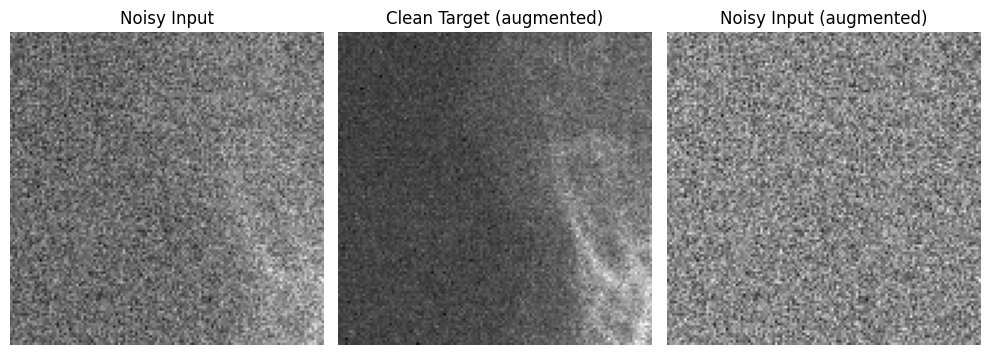

In [27]:
from scipy.ndimage import uniform_filter

class PseudoPairDataset(Dataset):
    """
    优化版：从单张图像生成伪配对数据
    优化点:
    1. 预计算所有有效 patch 位置，避免重复采样
    2. 支持数据增强（翻转、旋转）
    3. 支持固定种子实现噪声复现
    4. 向量化噪声生成，提高效率
    5. 支持简单高斯噪声与复杂信号依赖噪声
    """
    def __init__(self, img, patch_size=128, n_samples=2000,
                 noise_mode='complex',           # 'simple' 或 'complex'
                 # 复杂噪声超参（可传单值或 [min, max] 列表）
                 beta1=0.05,                      # 信号依赖噪声系数
                 beta2=0.0,                     # 信号独立噪声方差
                 bg=0.0,                         # 背景偏移量
                 alpha=0.1,                      # 噪声缩放比例
                 # 简单噪声参数
                 simple_std=0.05,
                 # 数据增强
                 augment=True,
                 # 复现性
                 noise_seed=None,
                 # 归一化选项
                 per_patch_minmax_norm=True):
        
        self.img = img.astype(np.float32)
        self.patch_size = patch_size
        self.n_samples = n_samples
        self.h, self.w = img.shape
        
        # 预计算所有有效的 patch 起始位置
        self.max_h = self.h - self.patch_size
        self.max_w = self.w - self.patch_size
        self.positions = None
        self._precompute_positions()
        
        self.noise_mode = noise_mode
        self.beta1 = beta1
        self.beta2 = beta2
        self.bg = bg
        self.alpha = alpha
        self.simple_std = simple_std
        self.augment = augment
        self.noise_seed = noise_seed
        self.per_patch_minmax_norm = per_patch_minmax_norm
        
        # 为每个样本预生成噪声种子（保证复现性）
        if noise_seed is not None:
            self.noise_seeds = np.random.RandomState(noise_seed).randint(0, 2**31, n_samples)

    def _precompute_positions(self):
        """预计算所有可能的 patch 位置索引"""
        if self.max_h > 0 and self.max_w > 0:
            self.positions = [(i, j) for i in range(self.max_h + 1) 
                                    for j in range(self.max_w + 1)]

    def _sample_param(self, param):
        """支持单值或区间随机采样"""
        if isinstance(param, (list, tuple)):
            return np.random.uniform(param[0], param[1])
        return float(param)

    def _apply_augment(self, patch):
        """随机数据增强：翻转 + 旋转"""
        if np.random.random() > 0.5:
            patch = np.fliplr(patch)
        if np.random.random() > 0.5:
            patch = np.flipud(patch)
        k = np.random.randint(0, 4)
        patch = np.rot90(patch, k)
        return patch.copy()

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        # 1. 获取 patch 位置（循环使用预计算的位置）
        if self.positions:
            pos_idx = idx % len(self.positions)
            h_start, w_start = self.positions[pos_idx]
        else:
            h_start = np.random.randint(0, self.max_h + 1)
            w_start = np.random.randint(0, self.max_w + 1)
        
        patch = self.img[h_start:h_start + self.patch_size,
                         w_start:w_start + self.patch_size].copy()

        # 2. 对 target 应用数据增强
        if self.augment:
            target = self._apply_augment(patch)
        else:
            target = patch

        # 3. 设置噪声随机种子（保证复现性）
        if self.noise_seed is not None:
            np.random.seed(self.noise_seeds[idx])

        # 4. 生成噪声输入
        if self.noise_mode == 'simple':
            z = np.random.normal(0, 1, patch.shape)
            noisy = patch + self.simple_std * z

        elif self.noise_mode == 'complex':
            # 采样当前迭代的超参数
            b1 = self._sample_param(self.beta1)
            b2 = self._sample_param(self.beta2)
            al = self._sample_param(self.alpha)

            # 防止除零或退化
            if al <= 1e-8 or b1 <= 1e-8 or b2 <= 1e-8:
                # 退化回简单加噪
                z = np.random.normal(0, 1, patch.shape)
                noisy = patch + 0.1 * z
                target = patch
            else:
                # 2. 局部均值滤波 (5x5 均值，等效 MATLAB fspecial('average',5))
                local_mean = uniform_filter(patch, size=5, mode='nearest')

                # 3. 计算空间自适应的标准差 sigma
                var = np.maximum(b1 * (local_mean - self.bg), 0) + b2
                sigma = np.sqrt(np.maximum(var, 0))

                # 4. 生成标准高斯噪声 z ~ N(0,1)
                z = np.random.normal(0, 1, patch.shape)

                # 5. 构建伪配对 (ZS-DeconvNet 核心逻辑)
                noisy  = patch + sigma * z * al          # 噪声放大 α 倍 -> 网络输入
                target = patch - (sigma * z) / al        # 噪声缩小 1/α 倍 -> 网络目标
        else:
            raise ValueError("noise_mode must be 'simple' or 'complex'")

        # 6. 逐块 Min-Max 归一化（与 MATLAB 逻辑一致，提升优化稳定性）
        if self.per_patch_minmax_norm:
            vmin = min(noisy.min(), target.min())
            vmax = max(noisy.max(), target.max())
            if vmax - vmin > 1e-8:
                noisy  = (noisy - vmin) / (vmax - vmin)
                target = (target - vmin) / (vmax - vmin)
            else:
                noisy = np.zeros_like(noisy)
                target = np.zeros_like(target)

        # 7. 添加通道维度 (1, H, W) 并转为 Tensor
        return torch.from_numpy(noisy[None]), torch.from_numpy(target[None])

# 测试数据加载
img = percentile_norm(load_image("../datasets/Microtubule/train_data/01.tif"))
print(f"图像形状：{img.shape}")

dataset = PseudoPairDataset(
    img, 
    patch_size=128, 
    n_samples=10,
    noise_seed=42,        # 新增：固定随机种子
    augment=True,         # 新增：启用数据增强
)
inp, gt = dataset[5]
print(f"输入形状：{inp.shape}, 目标形状：{gt.shape}")
print(f"有效 patch 位置数：{len(dataset.positions)}")


# 可视化伪配对数据
plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.imshow(inp.squeeze(), cmap="gray")
plt.title("Noisy Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gt.squeeze(), cmap="gray")
plt.title("Clean Target (augmented)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow((inp-gt).squeeze(), cmap="gray")
plt.title("Noisy Input (augmented)")
plt.axis("off")

plt.tight_layout()
plt.show()

## 4. 模型定义

In [6]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, n_conv=3):
        super().__init__()
        layers = []
        for i in range(n_conv):
            layers.append(nn.Conv2d(in_ch if i == 0 else out_ch, out_ch, 3, padding=1))
            layers.append(nn.ReLU(inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class Encoder(nn.Module):
    def __init__(self, in_ch=1, base_ch=32, depth=4, n_conv=3):
        super().__init__()
        self.blocks = nn.ModuleList()
        self.pools = nn.ModuleList()
        ch = in_ch
        for i in range(depth):
            out_ch = base_ch * (2 ** i)
            self.blocks.append(ConvBlock(ch, out_ch, n_conv))
            self.pools.append(nn.MaxPool2d(2))
            ch = out_ch
        self.out_ch = ch

    def forward(self, x):
        skips = []
        for blk, pool in zip(self.blocks, self.pools):
            x = blk(x)
            skips.append(x)
            x = pool(x)
        return x, skips


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, n_conv=3):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="nearest")
        layers = [nn.Conv2d(in_ch + skip_ch, out_ch, 3, padding=1), nn.ReLU(inplace=True)]
        cur = out_ch
        for _ in range(n_conv - 1):
            next_ch = max(out_ch // 2, 1)
            layers.extend([nn.Conv2d(cur, next_ch, 3, padding=1), nn.ReLU(inplace=True)])
            cur = next_ch
        self.conv = nn.Sequential(*layers)
        self.out_ch = cur

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="nearest")
        return self.conv(torch.cat([x, skip], dim=1))


class UNetStage(nn.Module):
    def __init__(self, in_ch=1, base_ch=32, depth=4, n_conv=3):
        super().__init__()
        self.encoder = Encoder(in_ch, base_ch, depth, n_conv)
        mid_ch = self.encoder.out_ch * 2
        self.mid = nn.Sequential(
            nn.Conv2d(self.encoder.out_ch, mid_ch, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(mid_ch, self.encoder.out_ch, 3, padding=1), nn.ReLU(inplace=True),
        )
        self.decoders = nn.ModuleList()
        cur_ch = self.encoder.out_ch
        for i in reversed(range(depth)):
            skip_ch = base_ch * (2 ** i)
            block = DecoderBlock(cur_ch, skip_ch, skip_ch, n_conv)
            self.decoders.append(block)
            cur_ch = block.out_ch
        self.out_ch = cur_ch

    def forward(self, x):
        x, skips = self.encoder(x)
        x = self.mid(x)
        for dec, skip in zip(self.decoders, reversed(skips)):
            x = dec(x, skip)
        return x


class DenoiseUNet(nn.Module):
    """单阶段去噪 UNet"""
    def __init__(self, base_ch=32, depth=4, n_conv=3):
        super().__init__()
        self.encoder = UNetStage(1, base_ch, depth, n_conv)
        self.out = nn.Conv2d(self.encoder.out_ch, 1, 3, padding=1)

    def forward(self, x):
        feat = self.encoder(x)
        return F.relu(self.out(feat))

# 测试模型
model = DenoiseUNet(base_ch=32, depth=4, n_conv=3).to(device)
x = torch.randn(1, 1, 128, 128).to(device)
y = model(x)
print(f"输入形状：{x.shape} -> 输出形状：{y.shape}")
print(f"模型参数量：{sum(p.numel() for p in model.parameters()):,}")

输入形状：torch.Size([1, 1, 128, 128]) -> 输出形状：torch.Size([1, 1, 128, 128])
模型参数量：6,470,929


## 5. 训练函数

In [5]:
def train_denoise(
    image_path="datasets/Microtubule/train_data/01.tif",
    out_dir="./output_denoise_notebook",
    patch_size=128,
    n_samples=2000,
    batch_size=4,
    epochs=30,
    lr=1e-4,
    lr_step=10,
    lr_gamma=0.5,
    depth=4,
    n_conv=3,
    base_ch=32,
    seed=42,
):
    set_seed(seed)
    ensure_dir(out_dir)
    
    print(f"设备：{device}")
    print(f"加载图像：{image_path}")
    img = percentile_norm(load_image(image_path))
    
    print("创建数据集...")
    dataset = PseudoPairDataset(img, patch_size, n_samples)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    
    print("初始化去噪模型...")
    model = DenoiseUNet(base_ch, depth, n_conv).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=lr_step, gamma=lr_gamma)
    criterion = nn.L1Loss()
    
    best_path = os.path.join(out_dir, "best_denoise.pt")
    best_loss = float("inf")
    history = []
    
    print("=" * 60)
    print(f"开始训练去噪模型，{epochs} epochs")
    print("=" * 60)
    
    model.train()
    for epoch in range(epochs):
        losses = []
        for inp, gt in loader:
            inp, gt = inp.to(device), gt.to(device)
            pred = model(inp)
            loss = criterion(pred, gt)
            
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        
        scheduler.step()
        mean_loss = np.mean(losses)
        lr_now = optimizer.param_groups[0]["lr"]
        history.append(mean_loss)
        
        print(f"epoch {epoch+1:03d}/{epochs:03d} | loss={mean_loss:.6f} lr={lr_now:.2e}")
        
        if mean_loss < best_loss:
            best_loss = mean_loss
            torch.save({
                "model": model.state_dict(),
                "cfg": {"base_ch": base_ch, "depth": depth, "n_conv": n_conv}
            }, best_path)
    
    # 绘制损失曲线
    plt.figure(figsize=(8, 4))
    plt.plot(history, 'b-', linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("L1 Loss")
    plt.title("Denoising Training Loss")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(out_dir, "loss_curve.png"), dpi=150)
    plt.show()
    
    print(f"\n训练完成！模型已保存：{best_path}")
    return best_path, history

## 6. 推理函数

In [7]:
@torch.no_grad()
def infer_denoise(image_path, checkpoint_path, out_dir="./output_denoise_notebook"):
    ensure_dir(out_dir)
    
    print(f"加载模型：{checkpoint_path}")
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    cfg = ckpt["cfg"]
    
    model = DenoiseUNet(cfg["base_ch"], cfg["depth"], cfg["n_conv"]).to(device)
    model.load_state_dict(ckpt["model"])
    model.eval()
    
    print(f"处理图像：{image_path}")
    img = percentile_norm(load_image(image_path))
    img_pad, padinfo = reflect_pad(img, multiple=2 ** cfg["depth"], margin=16)
    x = torch.from_numpy(img_pad[None, None]).float().to(device)
    
    pred = model(x)
    pred_np = crop_pad(pred.squeeze().cpu().numpy(), padinfo, scale=1)
    
    name = Path(image_path).stem
    pred_path = os.path.join(out_dir, f"{name}_denoised.tif")
    save_image(pred_path, percentile_norm(pred_np))
    
    print(f"去噪结果：min={pred_np.min():.4f}, max={pred_np.max():.4f}")
    print(f"已保存：{pred_path}")
    
    # 可视化
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap="gray")
    plt.title("Input (normalized)")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(img, cmap="gray")
    plt.title("Input (zoom)")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(pred_np, cmap="gray")
    plt.title("Denoised")
    plt.axis("off")
    
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{name}_denoise_result.png"), dpi=150)
    plt.show()
    
    return pred_path, pred_np

## 7. 开始训练

In [ ]:
# 训练参数
IMAGE_PATH = "datasets/Microtubule/train_data/01.tif"
OUT_DIR = "./output_denoise"
CHECKPOINT_PATH = "checkpoints/best_denoise.pt"
PATCH_SIZE = 128
N_SAMPLES = 2000
BATCH_SIZE = 4

EPOCHS = 30
LR = 1e-4
LR_STEP = 10
LR_GAMMA = 0.5

DEPTH = 4
N_CONV = 3
BASE_CH = 32

SEED = 42


In [ ]:

# 开始训练
checkpoint_path, history = train_denoise(
    image_path=IMAGE_PATH,
    out_dir=OUT_DIR,
    patch_size=PATCH_SIZE,
    n_samples=N_SAMPLES,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LR,
    lr_step=LR_STEP,
    lr_gamma=LR_GAMMA,
    depth=DEPTH,
    n_conv=N_CONV,
    base_ch=BASE_CH,
    seed=SEED,
)

## 8. 测试推理

加载模型：checkpoints/best_denoise.pt
处理图像：datasets/Microtubule/train_data/01.tif
去噪结果：min=0.0626, max=1.0273
已保存：./output_denoise_notebook/01_denoised.tif


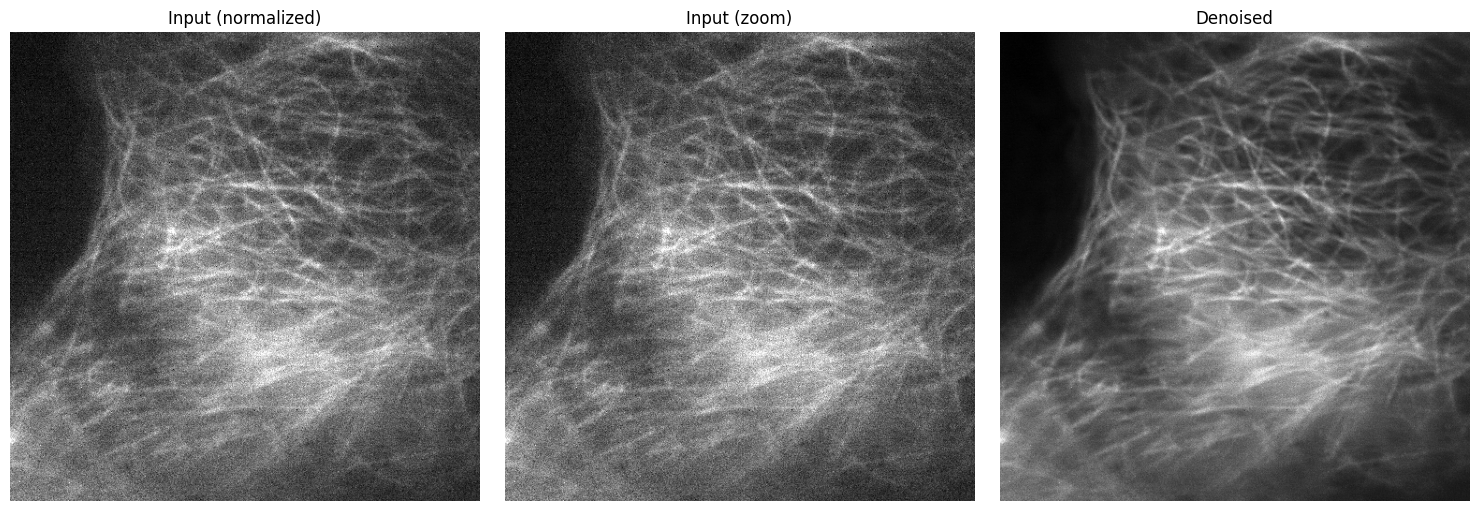

In [14]:
# 使用训练好的模型进行推理
pred_path, pred_np = infer_denoise(
    image_path=IMAGE_PATH,
    checkpoint_path=CHECKPOINT_PATH,
    out_dir=OUT_DIR,
)

## 9. 结果对比

In [1]:
# 加载并对比结果
original = load_image(IMAGE_PATH)
original_norm = percentile_norm(original)
denoise_result = load_image(pred_path)
denoise_result_norm = percentile_norm(denoise_result)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_norm, cmap="gray")
plt.title(f"Original ({original.shape[0]}x{original.shape[1]})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(denoise_result_norm, cmap="gray")
plt.title(f"Denoised ({denoise_result.shape[0]}x{denoise_result.shape[1]})")
plt.axis("off")

# 剖面线对比
center_y = original.shape[0] // 2
x = np.arange(original.shape[1])
plt.subplot(1, 3, 3)
plt.plot(x, original_norm[center_y, :], 'b-', label='Original', alpha=0.7)
plt.plot(x, denoise_result_norm[center_y, :], 'r-', label='Denoised', alpha=0.7)
plt.xlabel("Pixel")
plt.ylabel("Normalized Intensity")
plt.title(f"Horizontal Profile (y={center_y})")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "final_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\n所有结果已保存到：{OUT_DIR}")

NameError: name 'load_image' is not defined